<a href="https://colab.research.google.com/github/churongchen/churongchen/blob/main/CHEN_CHURONG_LAB2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Portfolio Optimization Lab 2
**Due: March 8th, 2026**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from scipy.optimize import minimize

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.float_format', '{:.4f}'.format)

---
## Section 1: Linear Programming

**Problem:**
$$\max \; 2x_1 - x_2 + 3x_3$$
$$\text{s.t.} \quad |x_1| + |x_2| + |x_3| \leq 1$$

### 1a) Reformulation as a Linear Program

Introduce auxiliary variables $u_i \geq |x_i|$, so $u_i \geq x_i$ and $u_i \geq -x_i$.

The LP becomes:
$$\max \; 2x_1 - x_2 + 3x_3$$
$$\text{s.t.} \quad u_1 + u_2 + u_3 \leq 1$$
$$u_i \geq x_i, \quad u_i \geq -x_i \quad \forall i$$
$$u_i \geq 0 \quad \forall i$$

In [2]:
x = cp.Variable(3)
u = cp.Variable(3)

objective = cp.Maximize(2*x[0] - x[1] + 3*x[2])
constraints = [
    cp.sum(u) <= 1,
    u >= x,
    u >= -x,
    u >= 0
]

prob = cp.Problem(objective, constraints)
prob.solve()

print("=== LP Solution ===")
print(f"Optimal value: {prob.value:.4f}")
print(f"x* = {x.value}")
print(f"u* = {u.value}")

=== LP Solution ===
Optimal value: 3.0000
x* = [0. 0. 1.]
u* = [0. 0. 1.]


### 1b) Graphical Solution

**Intuition:** The feasible set $|x_1| + |x_2| + |x_3| \leq 1$ is the $\ell_1$ ball (an octahedron in 3D). The objective coefficients are $(2, -1, 3)$. The maximum is achieved at an extreme point of the $\ell_1$ ball in the direction of the gradient.

The extreme points of the $\ell_1$ ball are $\pm e_i$ (the standard basis vectors and their negatives). The objective values at each extreme point are:
- $e_1 = (1,0,0)$: $2$
- $e_2 = (0,1,0)$: $-1$
- $e_3 = (0,0,1)$: $3$ ✓ **Maximum**
- $-e_1$: $-2$, $-e_2$: $1$, $-e_3$: $-3$

**Optimal solution:** $x^* = (0, 0, 1)$, **Optimal value = 3**

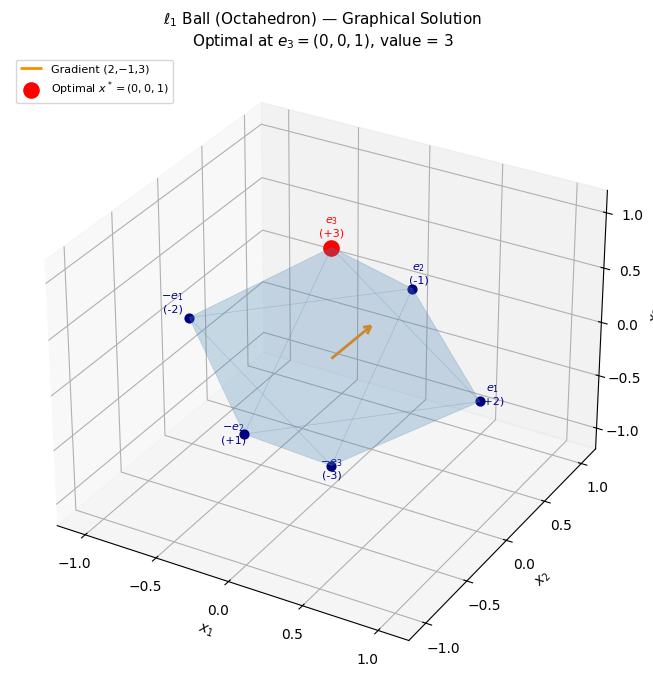

Optimal solution: x* = (0, 0, 1), Optimal value = 3


In [3]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# Build the l1-ball octahedron faces
vertices = np.array([[1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1]])
faces = [
    [vertices[0], vertices[2], vertices[4]],
    [vertices[0], vertices[3], vertices[4]],
    [vertices[1], vertices[2], vertices[4]],
    [vertices[1], vertices[3], vertices[4]],
    [vertices[0], vertices[2], vertices[5]],
    [vertices[0], vertices[3], vertices[5]],
    [vertices[1], vertices[2], vertices[5]],
    [vertices[1], vertices[3], vertices[5]],
]
poly = Poly3DCollection(faces, alpha=0.15, facecolor='steelblue', edgecolor='steelblue', linewidth=0.5)
ax.add_collection3d(poly)

# Plot and label all extreme points
extreme_pts = np.array([[1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1]])
obj_vals = [2*p[0] - p[1] + 3*p[2] for p in extreme_pts]
pt_labels = ['$e_1$','$-e_1$','$e_2$','$-e_2$','$e_3$','$-e_3$']
offsets = [(0.08,0,0),(-0.12,0,0),(0,0.08,0),(0,-0.12,0),(0,0,0.1),(0,0,-0.12)]

for pt, val, lbl, off in zip(extreme_pts, obj_vals, pt_labels, offsets):
    color = 'red' if val == max(obj_vals) else 'navy'
    size  = 80   if val == max(obj_vals) else 40
    ax.scatter(*pt, color=color, s=size, zorder=5)
    ax.text(pt[0]+off[0], pt[1]+off[1], pt[2]+off[2],
            f'{lbl}\n({val:+g})', fontsize=8, color=color, ha='center')

# Draw gradient direction arrow
grad = np.array([2, -1, 3])
grad_norm = grad / np.linalg.norm(grad) * 0.7
ax.quiver(0, 0, 0, grad_norm[0], grad_norm[1], grad_norm[2],
          color='darkorange', linewidth=2, arrow_length_ratio=0.15, label='Gradient (2,−1,3)')

# Highlight optimal point
ax.scatter(0, 0, 1, color='red', s=120, zorder=6, label='Optimal $x^*=(0,0,1)$')

ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.set_zlabel('$x_3$')
ax.set_title('$\\ell_1$ Ball (Octahedron) — Graphical Solution\n'
             'Optimal at $e_3=(0,0,1)$, value = 3', fontsize=11)
ax.legend(loc='upper left', fontsize=8)
ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.2,1.2); ax.set_zlim(-1.2,1.2)
plt.tight_layout()
plt.show()
print(f"Optimal solution: x* = (0, 0, 1), Optimal value = {max(obj_vals)}")

---
## Section 2: KKT Conditions

**Problem:**
$$\min_x \; x^\top Q x$$
$$\text{s.t.} \quad \sum_i x_i = 1, \quad \mu^\top x \geq r, \quad x \geq 0$$

With:
$$Q = \begin{pmatrix}4 & -0.25 & 1 \\ -0.25 & 6 & -1 \\ 1 & -1 & 1\end{pmatrix}, \quad \mu = \begin{pmatrix}1\\2\\5\end{pmatrix}, \quad r = 1.5$$

In [4]:
Q = np.array([[4, -0.25, 1],
              [-0.25, 6, -1],
              [1, -1, 1]])
mu = np.array([1, 2, 5])
r = 1.5
e = np.ones(3)

### 2a) KKT Conditions

The Lagrangian is:
$$L(x, \lambda, \nu, \gamma) = x^\top Q x - \lambda(\mu^\top x - r) + \nu(e^\top x - 1) - \gamma^\top x$$

**KKT Conditions:**

1. **Stationarity:** $\nabla_x L = 2Qx - \lambda\mu + \nu e - \gamma = 0$
2. **Primal feasibility:** $e^\top x = 1$, $\mu^\top x \geq r$, $x \geq 0$
3. **Dual feasibility:** $\lambda \geq 0$, $\gamma \geq 0$
4. **Complementary slackness:** $\lambda(\mu^\top x - r) = 0$, $\gamma_i x_i = 0 \; \forall i$

**Sufficiency:** Since $Q$ is positive definite (verify below) and the constraints are linear, the problem is convex. Therefore the KKT conditions are **necessary and sufficient**.

In [5]:
eigenvalues = np.linalg.eigvalsh(Q)
print("Eigenvalues of Q:", eigenvalues)
print("Q is positive definite:", np.all(eigenvalues > 0))

Eigenvalues of Q: [0.5516 4.1668 6.2816]
Q is positive definite: True


### 2b) Solve Using KKT Conditions

We'll solve by considering cases based on which constraints are active:

**Case: Return constraint active** ($\mu^\top x = r$) and some $x_i = 0$.

We try different combinations of active constraints and solve the resulting linear systems.

In [6]:
from itertools import combinations

def solve_kkt(Q, mu, e, r):
    """
    Solve the QP via KKT conditions by enumeration over active constraint sets.
    For each subset S of {0,1,2} (active long-only constraints, i.e., x_i=0),
    and return constraint active or not, solve the KKT system and check feasibility.
    """
    n = len(mu)
    best_val = np.inf
    best_x = None
    best_case = None

    for s in range(n+1):  # number of zero variables
        for zero_idx in combinations(range(n), s):
            free_idx = [i for i in range(n) if i not in zero_idx]
            nf = len(free_idx)
            if nf == 0:
                continue

            for ret_active in [True, False]:
                # 2*Q[free,free]*x[free] - lambda*mu[free] + nu*e[free] = 0
                # e[free]^T x[free] = 1
                # mu[free]^T x[free] = r  (if ret_active)

                Qf = Q[np.ix_(free_idx, free_idx)]
                muf = mu[free_idx]
                ef = np.ones(nf)

                if ret_active:
                    A = np.zeros((nf+2, nf+2))
                    A[:nf, :nf] = 2*Qf
                    A[:nf, nf] = -muf
                    A[:nf, nf+1] = ef
                    A[nf, :nf] = ef
                    A[nf+1, :nf] = muf
                    b = np.zeros(nf+2)
                    b[nf] = 1
                    b[nf+1] = r
                else:
                    A = np.zeros((nf+1, nf+1))
                    A[:nf, :nf] = 2*Qf
                    A[:nf, nf] = ef
                    A[nf, :nf] = ef
                    b = np.zeros(nf+1)
                    b[nf] = 1

                try:
                    sol = np.linalg.solve(A, b)
                except np.linalg.LinAlgError:
                    continue

                xf = sol[:nf]
                lam = sol[nf] if ret_active else 0.0
                nu = sol[nf+1] if ret_active else sol[nf]

                x_full = np.zeros(n)
                for ii, fi in enumerate(free_idx):
                    x_full[fi] = xf[ii]

                if not np.all(x_full >= -1e-8):
                    continue
                if not (mu @ x_full >= r - 1e-8):
                    continue
                if ret_active and lam < -1e-8:
                    continue

                gamma = 2*Q @ x_full - lam*mu + nu*e
                if not np.all(gamma >= -1e-8):
                    continue

                val = x_full @ Q @ x_full
                if val < best_val:
                    best_val = val
                    best_x = x_full.copy()
                    best_case = {'zero_idx': zero_idx, 'ret_active': ret_active,
                                 'lambda': lam, 'nu': nu, 'gamma': gamma}

    return best_x, best_val, best_case


x_kkt, val_kkt, case = solve_kkt(Q, mu, e, r)

print("=== KKT Solution ===")
print(f"Optimal x* = {x_kkt}")
print(f"Optimal value (x^T Q x) = {val_kkt:.6f}")
print(f"Portfolio return: {mu @ x_kkt:.4f} (target r={r})")
print(f"Budget constraint: {e @ x_kkt:.4f}")
print(f"Return constraint active: {case['ret_active']}")
print(f"lambda = {case['lambda']:.4f}, nu = {case['nu']:.4f}")
print(f"gamma = {case['gamma']}")

=== KKT Solution ===
Optimal x* = [0.     0.2222 0.7778]
Optimal value (x^T Q x) = 0.555556
Portfolio return: 4.3333 (target r=1.5)
Budget constraint: 1.0000
Return constraint active: False
lambda = 0.0000, nu = -1.1111
gamma = [ 0.3333 -0.      0.    ]


In [7]:
x_var = cp.Variable(3)
prob2 = cp.Problem(
    cp.Minimize(cp.quad_form(x_var, Q)),
    [e @ x_var == 1, mu @ x_var >= r, x_var >= 0]
)
prob2.solve()
print("=== CVXPY Verification ===")
print(f"Optimal x* = {x_var.value}")
print(f"Optimal value = {prob2.value:.6f}")

=== CVXPY Verification ===
Optimal x* = [-0.      0.2222  0.7778]
Optimal value = 0.555556


### 2c) Sensitivity to Expected Return (Parameter r)

The sensitivity of the optimal value to changes in $r$ is given by the dual variable (Lagrange multiplier) $\lambda^*$ associated with the return constraint:

$$\frac{d f^*}{d r} = -\lambda^*$$

This follows from the envelope theorem.

Dual variable lambda* = 0.000000
Sensitivity d(f*)/d(r) = -0.000000



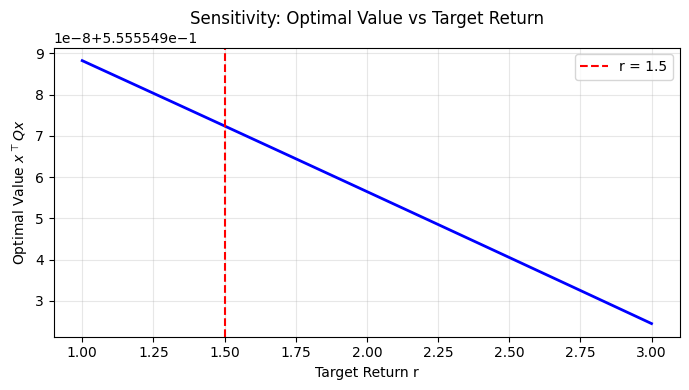

In [8]:
print(f"Dual variable lambda* = {case['lambda']:.6f}")
print(f"Sensitivity d(f*)/d(r) = -{case['lambda']:.6f}")
print()

r_vals = np.linspace(1.0, 3.0, 50)
opt_vals = []
for r_test in r_vals:
    xv = cp.Variable(3)
    p = cp.Problem(cp.Minimize(cp.quad_form(xv, Q)),
                   [e @ xv == 1, mu @ xv >= r_test, xv >= 0])
    p.solve(solver=cp.SCS, verbose=False)
    opt_vals.append(p.value if p.status not in ['infeasible', 'unbounded'] else np.nan)

plt.figure(figsize=(7, 4))
plt.plot(r_vals, opt_vals, 'b-', linewidth=2)
plt.axvline(r, color='red', linestyle='--', label=f'r = {r}')
plt.xlabel('Target Return r')
plt.ylabel('Optimal Value $x^\\top Q x$')
plt.title('Sensitivity: Optimal Value vs Target Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 3: Portfolio Optimization

### (a) Data Estimation

In [9]:
# Define the universe of stocks
tickers = {
    'Internet': ['META', 'SNAP', 'GOOG', 'BIDU'],
    'Oil':      ['XOM', 'CVX', 'SHEL', 'BP'],
    'Banks':    ['JPM', 'WFC', 'BAC', 'C'],
    'Pharma':   ['JNJ', 'PFE', 'MRK', 'LLY'],
}
all_tickers = [t for group in tickers.values() for t in group]
market_ticker = ['^GSPC']

industries = {}
for ind, stocks in tickers.items():
    for s in stocks:
        industries[s] = ind

print(f"Total stocks: {len(all_tickers)}")
print("Tickers:", all_tickers)

Total stocks: 16
Tickers: ['META', 'SNAP', 'GOOG', 'BIDU', 'XOM', 'CVX', 'SHEL', 'BP', 'JPM', 'WFC', 'BAC', 'C', 'JNJ', 'PFE', 'MRK', 'LLY']


In [10]:
prices = pd.read_csv("prices.csv", sep=";")
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.pivot(index="date", columns="symbol", values="adjusted")
prices = prices.dropna()
print(f"Price data shape: {prices.shape}")
prices.tail()

Price data shape: (1259, 17)


symbol,BAC,BIDU,BP,C,CVX,GOOG,JNJ,JPM,LLY,META,MRK,PFE,SHEL,SNAP,WFC,XOM,^GSPC
date,,,,,,,,,,,,,,,,,
2022-12-23,32.2608,111.6100,34.6700,43.8277,175.8455,89.8100,176.2126,129.3026,366.7136,118.0400,111.0877,51.3585,57.2481,8.5800,40.7202,107.8501,3844.8201
2022-12-27,32.3204,116.4800,34.6997,43.9565,178.0560,87.9300,176.1629,129.7557,363.7033,116.8800,111.3459,50.6649,57.3373,8.5600,40.7799,109.3486,3829.2500
2022-12-28,32.5588,111.6000,34.2442,44.1842,175.4292,86.4600,175.3985,130.4649,364.0422,115.6200,110.3131,50.3379,56.0393,8.5500,40.8594,107.5524,3783.2200
2022-12-29,32.9264,115.1000,34.3630,44.7189,176.7574,88.9500,176.2920,131.2134,365.8364,120.2600,110.0549,50.8631,56.1483,8.8100,41.0680,108.3661,3849.2800
2022-12-30,32.9066,114.3800,34.5908,44.7883,177.9172,88.7300,175.3885,132.0802,364.6602,120.3400,110.1840,50.7739,56.4257,8.9500,41.0283,109.4577,3839.5000


In [11]:
log_returns = np.log(prices / prices.shift(1)).dropna()

stock_returns = log_returns[all_tickers]

T = len(stock_returns)
mu_daily = stock_returns.mean()              # daily mean
mu_annual = mu_daily * 252                   # annualized
Omega_daily = stock_returns.cov().values     # daily cov
Omega_annual = Omega_daily * 252             # annualized

print("Annualized Expected Returns:")
print(mu_annual.to_string())
print(f"\nCovariance matrix shape: {Omega_annual.shape}")

Annualized Expected Returns:
symbol
META   -0.0822
SNAP   -0.1028
GOOG    0.1023
BIDU   -0.1505
XOM     0.1048
CVX     0.1123
SHEL    0.0113
BP      0.0188
JPM     0.0725
WFC    -0.0496
BAC     0.0424
C      -0.0677
JNJ     0.0742
PFE     0.1153
MRK     0.1767
LLY     0.3123

Covariance matrix shape: (16, 16)


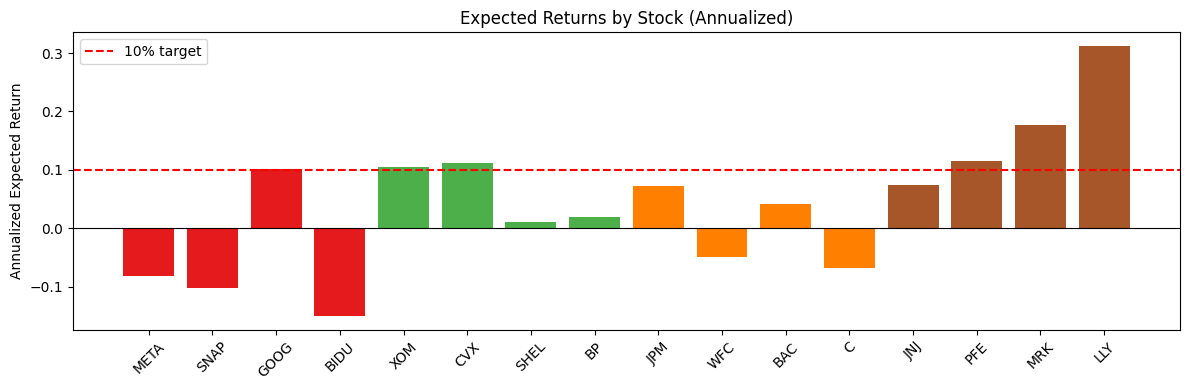

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
colors_bar = [plt.cm.Set1(i/4) for t in all_tickers
              for i, ind in enumerate(tickers.keys()) if t in tickers[ind]]
ax.bar(all_tickers, mu_annual.values, color=colors_bar)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.10, color='red', linestyle='--', label='10% target')
ax.set_ylabel('Annualized Expected Return')
ax.set_title('Expected Returns by Stock (Annualized)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
def report_portfolio(w, mu_vec, Omega, label="Portfolio"):
    ret = mu_vec @ w
    var = w @ Omega @ w
    std = np.sqrt(var)
    sharpe = ret / std if std > 0 else np.nan
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Portfolio Return:   {ret:.4f} ({ret*100:.2f}%)")
    print(f"  Portfolio Variance: {var:.6f}")
    print(f"  Portfolio Std Dev:  {std:.4f}")
    print(f"  Sharpe Ratio:       {sharpe:.4f}")
    weights_df = pd.Series(w, index=all_tickers)
    nonzero = weights_df[weights_df.abs() > 1e-4]
    print(f"  Non-zero weights ({len(nonzero)}):")
    for t, ww in nonzero.items():
        print(f"    {t:6s}: {ww:.4f}  ({ww*100:.2f}%)")
    return ret, var

mu_vec = mu_annual.values
n = len(all_tickers)
e_vec = np.ones(n)
b = 0.10  # 10% target return

---
## Model 1: Minimum Variance with Target Return

$$\min_w \; w^\top \Omega w \quad \text{s.t.} \quad \mu^\top w \geq b, \; e^\top w = 1, \; w \geq 0$$

### Model 1b: Full Constraints (Budget + Long-Only + Target Return)

In [14]:
def min_variance(mu_vec, Omega, b, budget_eq=True, long_only=True):
    w = cp.Variable(n)
    constraints = [mu_vec @ w >= b]
    if budget_eq:
        constraints.append(e_vec @ w == 1)
    else:
        constraints.append(e_vec @ w <= 1)
    if long_only:
        constraints.append(w >= 0)
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, Omega)), constraints)
    prob.solve(solver=cp.SCS)
    return w.value, prob.value

w1b, v1b = min_variance(mu_vec, Omega_annual, b)
report_portfolio(w1b, mu_vec, Omega_annual, "Model 1b: Min Variance (Budget=Eq, Long-Only)")


  Model 1b: Min Variance (Budget=Eq, Long-Only)
  Portfolio Return:   0.1000 (10.00%)
  Portfolio Variance: 0.033980
  Portfolio Std Dev:  0.1843
  Sharpe Ratio:       0.5425
  Non-zero weights (9):
    SNAP  : 0.0034  (0.34%)
    GOOG  : 0.0624  (6.24%)
    BIDU  : 0.0487  (4.87%)
    XOM   : 0.0595  (5.95%)
    SHEL  : 0.0204  (2.04%)
    JNJ   : 0.4158  (41.58%)
    PFE   : 0.1167  (11.67%)
    MRK   : 0.2564  (25.64%)
    LLY   : 0.0167  (1.67%)


(np.float64(0.09999973699626435), np.float64(0.03398021720686788))

### Model 1c: Relax Long-Only Constraint (Allow Short Positions)

In [15]:
w1c, v1c = min_variance(mu_vec, Omega_annual, b, budget_eq=True, long_only=False)
report_portfolio(w1c, mu_vec, Omega_annual, "Model 1c: Min Variance (No Long-Only)")


  Model 1c: Min Variance (No Long-Only)
  Portfolio Return:   0.1082 (10.82%)
  Portfolio Variance: 0.032363
  Portfolio Std Dev:  0.1799
  Sharpe Ratio:       0.6014
  Non-zero weights (16):
    META  : 0.0081  (0.81%)
    SNAP  : 0.0054  (0.54%)
    GOOG  : 0.0726  (7.26%)
    BIDU  : 0.0544  (5.44%)
    XOM   : 0.1585  (15.85%)
    CVX   : -0.1395  (-13.95%)
    SHEL  : 0.0637  (6.37%)
    BP    : 0.0196  (1.96%)
    JPM   : 0.1979  (19.79%)
    WFC   : -0.0017  (-0.17%)
    BAC   : -0.0871  (-8.71%)
    C     : -0.1397  (-13.97%)
    JNJ   : 0.4256  (42.56%)
    PFE   : 0.1139  (11.39%)
    MRK   : 0.2531  (25.31%)
    LLY   : -0.0047  (-0.47%)


(np.float64(0.10819131096303264), np.float64(0.032362921885457745))

### Model 1d: Relax Budget Constraint (e^T w ≤ 1, w ≥ 0)

In [16]:
w1d, v1d = min_variance(mu_vec, Omega_annual, b, budget_eq=False, long_only=True)
report_portfolio(w1d, mu_vec, Omega_annual, "Model 1d: Min Variance (Relaxed Budget, Long-Only)")


  Model 1d: Min Variance (Relaxed Budget, Long-Only)
  Portfolio Return:   0.1000 (10.00%)
  Portfolio Variance: 0.008583
  Portfolio Std Dev:  0.0926
  Sharpe Ratio:       1.0794
  Non-zero weights (2):
    MRK   : 0.1027  (10.27%)
    LLY   : 0.2621  (26.21%)


(np.float64(0.09999924438380212), np.float64(0.008582801282604151))

### Model 1e: Industry Constraints (Banks ≤ 15%, Oil ≤ 10%)

In [17]:
banks_idx = [all_tickers.index(t) for t in tickers['Banks']]
oil_idx   = [all_tickers.index(t) for t in tickers['Oil']]

w = cp.Variable(n)
constraints = [
    mu_vec @ w >= b,
    e_vec @ w == 1,
    w >= 0,
    cp.sum(w[banks_idx]) <= 0.15,
    cp.sum(w[oil_idx]) <= 0.10,
]
prob1e = cp.Problem(cp.Minimize(cp.quad_form(w, Omega_annual)), constraints)
prob1e.solve(solver=cp.SCS)
w1e = w.value
report_portfolio(w1e, mu_vec, Omega_annual, "Model 1e: Min Variance (Industry Constraints)")
print(f"\n  Banks exposure: {w1e[banks_idx].sum():.4f} (≤0.15)")
print(f"  Oil exposure:   {w1e[oil_idx].sum():.4f} (≤0.10)")


  Model 1e: Min Variance (Industry Constraints)
  Portfolio Return:   0.1000 (10.00%)
  Portfolio Variance: 0.033980
  Portfolio Std Dev:  0.1843
  Sharpe Ratio:       0.5425
  Non-zero weights (9):
    SNAP  : 0.0034  (0.34%)
    GOOG  : 0.0624  (6.24%)
    BIDU  : 0.0487  (4.87%)
    XOM   : 0.0595  (5.95%)
    SHEL  : 0.0204  (2.04%)
    JNJ   : 0.4158  (41.58%)
    PFE   : 0.1167  (11.67%)
    MRK   : 0.2564  (25.64%)
    LLY   : 0.0167  (1.67%)

  Banks exposure: -0.0000 (≤0.15)
  Oil exposure:   0.0799 (≤0.10)


---
## Model 2: Maximize Sharpe Ratio

Using the variable substitution $z = w\kappa$ where $\mu^\top z = 1$:

$$\min_z \; z^\top \Omega z \quad \text{s.t.} \quad \mu^\top z = 1, \; e^\top z = \kappa, \; z \geq 0, \; \kappa > 0$$

Then $w = z / \kappa$.

In [18]:
def max_sharpe(mu_vec, Omega, budget_eq=True, long_only=True,
               banks_constraint=False, oil_constraint=False):
    """
    Maximize Sharpe Ratio using the z = w*kappa reformulation.
    mu^T z = 1, minimize z^T Omega z.
    w = z / (e^T z)
    """
    z = cp.Variable(n)
    kappa = cp.Variable()

    constraints = [mu_vec @ z == 1, kappa >= 0]
    if budget_eq:
        constraints.append(e_vec @ z == kappa)
    else:
        constraints.append(e_vec @ z <= kappa)
    if long_only:
        constraints.append(z >= 0)
    if banks_constraint:
        constraints.append(cp.sum(z[banks_idx]) <= 0.15 * kappa)
    if oil_constraint:
        constraints.append(cp.sum(z[oil_idx]) <= 0.10 * kappa)

    prob = cp.Problem(cp.Minimize(cp.quad_form(z, Omega)), constraints)
    prob.solve(solver=cp.SCS)

    if z.value is None:
        return None, None
    w_opt = z.value / (e_vec @ z.value)
    return w_opt, prob.value

w2b, v2b = max_sharpe(mu_vec, Omega_annual)
report_portfolio(w2b, mu_vec, Omega_annual, "Model 2b: Max Sharpe (Budget=Eq, Long-Only)")


  Model 2b: Max Sharpe (Budget=Eq, Long-Only)
  Portfolio Return:   0.2741 (27.41%)
  Portfolio Variance: 0.064504
  Portfolio Std Dev:  0.2540
  Sharpe Ratio:       1.0793
  Non-zero weights (2):
    MRK   : 0.2815  (28.15%)
    LLY   : 0.7185  (71.85%)


(np.float64(0.274126059423369), np.float64(0.06450420856626507))

### Model 2c: Relax Long-Only Constraint

In [19]:
w2c, v2c = max_sharpe(mu_vec, Omega_annual, long_only=False)
report_portfolio(w2c, mu_vec, Omega_annual, "Model 2c: Max Sharpe (No Long-Only)")


  Model 2c: Max Sharpe (No Long-Only)
  Portfolio Return:   0.8612 (86.12%)
  Portfolio Variance: 0.257611
  Portfolio Std Dev:  0.5076
  Sharpe Ratio:       1.6968
  Non-zero weights (16):
    META  : -0.4918  (-49.18%)
    SNAP  : -0.0033  (-0.33%)
    GOOG  : 0.7261  (72.61%)
    BIDU  : -0.2039  (-20.39%)
    XOM   : 0.4821  (48.21%)
    CVX   : 0.2504  (25.04%)
    SHEL  : -0.3823  (-38.23%)
    BP    : 0.0054  (0.54%)
    JPM   : 1.4737  (147.37%)
    WFC   : -0.7964  (-79.64%)
    BAC   : 0.3425  (34.25%)
    C     : -1.2220  (-122.20%)
    JNJ   : -0.8784  (-87.84%)
    PFE   : -0.1033  (-10.33%)
    MRK   : 0.6487  (64.87%)
    LLY   : 1.1524  (115.24%)


(np.float64(0.8612091506298654), np.float64(0.2576107473160142))

### Model 2d: Relax Budget Constraint

In [20]:
w2d, v2d = max_sharpe(mu_vec, Omega_annual, budget_eq=False, long_only=True)
report_portfolio(w2d, mu_vec, Omega_annual, "Model 2d: Max Sharpe (Relaxed Budget, Long-Only)")


  Model 2d: Max Sharpe (Relaxed Budget, Long-Only)
  Portfolio Return:   0.2741 (27.41%)
  Portfolio Variance: 0.064504
  Portfolio Std Dev:  0.2540
  Sharpe Ratio:       1.0793
  Non-zero weights (2):
    MRK   : 0.2815  (28.15%)
    LLY   : 0.7185  (71.85%)


(np.float64(0.274126059093268), np.float64(0.06450420581213903))

### Model 2e: Industry Constraints

In [21]:
w2e, v2e = max_sharpe(mu_vec, Omega_annual,
                      banks_constraint=True, oil_constraint=True)
report_portfolio(w2e, mu_vec, Omega_annual, "Model 2e: Max Sharpe (Industry Constraints)")
if w2e is not None:
    print(f"\n  Banks exposure: {w2e[banks_idx].sum():.4f} (≤0.15)")
    print(f"  Oil exposure:   {w2e[oil_idx].sum():.4f} (≤0.10)")


  Model 2e: Max Sharpe (Industry Constraints)
  Portfolio Return:   0.2741 (27.41%)
  Portfolio Variance: 0.064504
  Portfolio Std Dev:  0.2540
  Sharpe Ratio:       1.0793
  Non-zero weights (2):
    MRK   : 0.2815  (28.15%)
    LLY   : 0.7185  (71.85%)

  Banks exposure: -0.0000 (≤0.15)
  Oil exposure:   -0.0000 (≤0.10)
